In [1]:
%pip install openpyxl

import pandas as pd

apps = pd.read_excel('googleplaystore.xlsx', engine='openpyxl')
reviews = pd.read_excel('googleplaystore_user_reviews.xlsx', engine='openpyxl')

# 1. Basic shape and structure
print(apps.shape)
print(apps.info())

# 2. Peek at the actual values
apps.head()

Note: you may need to restart the kernel to use updated packages.
(10841, 13)
<class 'pandas.DataFrame'>
RangeIndex: 10841 entries, 0 to 10840
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   App             10840 non-null  str    
 1   Category        10841 non-null  object 
 2   Rating          9367 non-null   float64
 3   Reviews         10841 non-null  object 
 4   Size            10841 non-null  str    
 5   Installs        10841 non-null  object 
 6   Type            10840 non-null  object 
 7   Price           10841 non-null  object 
 8   Content Rating  10840 non-null  str    
 9   Genres          10841 non-null  object 
 10  Last Updated    10841 non-null  object 
 11  Current Ver     10833 non-null  object 
 12  Android Ver     10838 non-null  str    
dtypes: float64(1), object(8), str(4)
memory usage: 1.1+ MB
None


,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19M,"10,000+",Free,0,Everyone,Art & Design,2018-01-07 00:00:00,1.0.0,4.0.3 and up
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14M,"500,000+",Free,0,Everyone,Art & Design;Pretend Play,2018-01-15 00:00:00,2.0.0,4.0.3 and up
2,"U Launcher Lite ‚Äì FREE Live Cool Themes, Hid...",ART_AND_DESIGN,4.7,87510,8.7M,"5,000,000+",Free,0,Everyone,Art & Design,2018-08-01 00:00:00,1.2.4,4.0.3 and up
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25M,"50,000,000+",Free,0,Teen,Art & Design,2018-06-08 00:00:00,Varies with device,4.2 and up
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8M,"100,000+",Free,0,Everyone,Art & Design;Creativity,2018-06-20 00:00:00,1.1,4.4 and up


In [2]:
apps[pd.to_numeric(apps['Reviews'], errors='coerce').isna()]

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
10472,Life Made WI-Fi Touchscreen Photo Frame,1.9,19.0,3.0M,"1,000+",Free,0,Everyone,NaN,2018-02-11 00:00:00,1.0.19,4.0 and up,NaN


In [6]:
# Locate the row by its index (10472) and fix it column by column
apps.loc[10472, 'Category'] = 'LIFESTYLE'
apps.loc[10472, 'Rating'] = 1.9
apps.loc[10472, 'Reviews'] = 19
apps.loc[10472, 'Size'] = '3.0M'
apps.loc[10472, 'Installs'] = '1,000+'
apps.loc[10472, 'Type'] = 'Free'
apps.loc[10472, 'Price'] = '0'
apps.loc[10472, 'Content Rating'] = 'Everyone'
apps.loc[10472, 'Genres'] = 'Lifestyle'
apps.loc[10472, 'Last Updated'] = '2018-02-11'
apps.loc[10472, 'Current Ver'] = '1.0.19'
apps.loc[10472, 'Android Ver'] = '4.0 and up'

# Verify the fix
apps.loc[10472]

App               Life Made WI-Fi Touchscreen Photo Frame
Category                                        LIFESTYLE
Rating                                                1.9
Reviews                                                19
Size                                                 3.0M
Installs                                           1,000+
Type                                                 Free
Price                                                   0
Content Rating                                   Everyone
Genres                                          Lifestyle
Last Updated                                   2018-02-11
Current Ver                                        1.0.19
Android Ver                                    4.0 and up
Name: 10472, dtype: object

In [7]:
# Find rows where Installs became NaN after cleaning
apps[apps['Installs'].isna()]

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver


In [8]:
# Look at all unique values in Installs to spot any other weird entries
apps['Installs'].unique()


array(['10,000+', '500,000+', '5,000,000+', '50,000,000+', '100,000+',
       '50,000+', '1,000,000+', '10,000,000+', '5,000+', '100,000,000+',
       '1,000,000,000+', '1,000+', '500,000,000+', '50+', '100+', '500+',
       '10+', '1+', '5+', '0+', 0], dtype=object)

In [9]:
# Reload fresh and re-apply our row fix
apps = pd.read_excel('googleplaystore.xlsx')
apps.loc[10472, 'Category'] = 'LIFESTYLE'
apps.loc[10472, 'Rating'] = 1.9
apps.loc[10472, 'Reviews'] = 19
apps.loc[10472, 'Size'] = '3.0M'
apps.loc[10472, 'Installs'] = '1,000+'
apps.loc[10472, 'Type'] = 'Free'
apps.loc[10472, 'Price'] = '0'
apps.loc[10472, 'Content Rating'] = 'Everyone'
apps.loc[10472, 'Genres'] = 'Lifestyle'
apps.loc[10472, 'Last Updated'] = '2018-02-11'
apps.loc[10472, 'Current Ver'] = '1.0.19'
apps.loc[10472, 'Android Ver'] = '4.0 and up'

# Reviews: straightforward, no missing values
apps['Reviews'] = apps['Reviews'].astype(int)

# Installs: strip symbols, then use nullable Int64 to allow the 1 missing value
apps['Installs'] = apps['Installs'].str.replace('+', '', regex=False)
apps['Installs'] = apps['Installs'].str.replace(',', '', regex=False)
apps['Installs'] = apps['Installs'].astype('Int64')   # capital I — nullable

# Price: strip "$", convert to float (float already supports NaN natively)
apps['Price'] = apps['Price'].str.replace('$', '', regex=False)
apps['Price'] = apps['Price'].astype(float)

# Confirm it worked
print(apps[['Reviews', 'Installs', 'Price']].dtypes)
print(apps.loc[9148, ['App', 'Installs', 'Type']])  # check our NaN row specifically

Reviews       int64
Installs      Int64
Price       float64
dtype: object
App         Command & Conquer: Rivals
Installs                         <NA>
Type                              NaN
Name: 9148, dtype: object


In [10]:
# Confirm pandas automatically excludes NaN
print("Total rows:", len(apps))
print("Rows with non-null Rating:", apps['Rating'].count())
print("Average rating (NaN auto-excluded):", apps['Rating'].mean())


Total rows: 10841
Rows with non-null Rating: 9367
Average rating (NaN auto-excluded): 4.191512757553111


In [11]:
# Check 1: fully identical rows (every single column matches)
print("Fully identical duplicate rows:", apps.duplicated().sum())

# Check 2: just the App name repeated (other columns may differ)
print("Duplicate App names:", apps.duplicated(subset='App').sum())

Fully identical duplicate rows: 483
Duplicate App names: 1181


In [12]:
apps[apps['App'] == 'Instagram']


,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
2545,Instagram,SOCIAL,4.5,66577313,Varies with device,1000000000,Free,NaN,Teen,Social,2018-07-31 00:00:00,Varies with device,Varies with device
2604,Instagram,SOCIAL,4.5,66577446,Varies with device,1000000000,Free,NaN,Teen,Social,2018-07-31 00:00:00,Varies with device,Varies with device
2611,Instagram,SOCIAL,4.5,66577313,Varies with device,1000000000,Free,NaN,Teen,Social,2018-07-31 00:00:00,Varies with device,Varies with device
3909,Instagram,SOCIAL,4.5,66509917,Varies with device,1000000000,Free,NaN,Teen,Social,2018-07-31 00:00:00,Varies with device,Varies with device


In [13]:
import pandas as pd

# Load
apps = pd.read_excel('googleplaystore.xlsx')

# Fix the shifted row (Life Made WI-Fi Touchscreen Photo Frame)
apps.loc[10472, 'Category'] = 'LIFESTYLE'
apps.loc[10472, 'Rating'] = 1.9
apps.loc[10472, 'Reviews'] = 19
apps.loc[10472, 'Size'] = '3.0M'
apps.loc[10472, 'Installs'] = '1,000+'
apps.loc[10472, 'Type'] = 'Free'
apps.loc[10472, 'Price'] = '0'
apps.loc[10472, 'Content Rating'] = 'Everyone'
apps.loc[10472, 'Genres'] = 'Lifestyle'
apps.loc[10472, 'Last Updated'] = '2018-02-11'
apps.loc[10472, 'Current Ver'] = '1.0.19'
apps.loc[10472, 'Android Ver'] = '4.0 and up'

# Convert Reviews, Installs, Price to numeric
apps['Reviews'] = apps['Reviews'].astype(int)
apps['Installs'] = apps['Installs'].str.replace('+', '', regex=False)
apps['Installs'] = apps['Installs'].str.replace(',', '', regex=False)
apps['Installs'] = apps['Installs'].astype('Int64')
apps['Price'] = apps['Price'].str.replace('$', '', regex=False)
apps['Price'] = apps['Price'].astype(float)

print("Loaded and cleaned:", apps.shape)

Loaded and cleaned: (10841, 13)


In [14]:
# Sort so the highest Reviews count comes first for each App, then keep only the first occurrence
apps = apps.sort_values('Reviews', ascending=False)
apps = apps.drop_duplicates(subset='App', keep='first')

# Confirm the result
print("New total rows:", len(apps))
print("Remaining duplicate App names:", apps.duplicated(subset='App').sum())

New total rows: 9660
Remaining duplicate App names: 0


In [15]:
apps[apps['App'].str.contains('BL', na=False) & apps['App'].str.contains('恋', na=False)]


,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver


In [16]:
# Search for the specific garbled character pattern
apps[apps['App'].str.contains('Â', na=False)]



,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
9222,Ëã±Êº¢Â≠óÂÖ∏ EC Dictionary,FAMILY,4.3,55408,Varies with device,1000000,Free,NaN,Everyone,Education,2018-01-08 00:00:00,Varies with device,Varies with device
313,"Êº´Âíñ Comics - Manga,Novel and Stories",COMICS,4.1,12088,21M,1000000,Free,NaN,Mature 17+,Comics,2018-07-06 00:00:00,2.3.1,4.0.3 and up
6406,BL Â•≥ÊÄßÂêë„ÅëÊÅãÊÑõ„Ç≤„Éº„É†‚óÜ‰ø∫„Éó„É™„ÇØ„...,FAMILY,4.2,3379,62M,100000,Free,NaN,Mature 17+,Simulation,2017-03-23 00:00:00,1.6.3,2.3.3 and up
1488,"‰πêÂ±ãÁΩë: Buying a house, selling a house, re...",HOUSE_AND_HOME,3.7,2248,15M,100000,Free,NaN,Everyone,House & Home,2018-08-03 00:00:00,v3.1.1,4.0 and up
6417,BL Â•≥ÊÄßÂêë„ÅëÊÅãÊÑõ„Ç≤„Éº„É†‚óÜ„Åî„Åè„É°„É≥,FAMILY,4.2,1901,8.2M,100000,Free,NaN,Mature 17+,Simulation,2016-07-07 00:00:00,1.3.0,2.3.3 and up
7463,CK Âàù‰∏Ä ÂçÅ‰∫î,LIFESTYLE,4.0,294,153k,10000,Free,NaN,Everyone,Lifestyle,2013-07-03 00:00:00,1.0.12,2.1 and up
10109,ÂìàÂìàÂßÜÁâπ‰∏çEY,COMMUNICATION,NaN,239,18M,10000,Free,NaN,Everyone,Communication,2018-07-31 00:00:00,1.3.4,4.4 and up
5698,Êó•Êú¨AVÂéÜÂè≤,BOOKS_AND_REFERENCE,4.1,215,30M,10000,Free,NaN,Teen,Books & Reference,2018-03-06 00:00:00,1.2,4.0 and up
10174,CNY Slots : Gong Xi Fa Cai ÂèëË¥¢Êú∫,GAME,3.6,33,71M,5000,Free,NaN,Teen,Casino,2017-06-06 00:00:00,1.2,4.0.3 and up
5513,‰∏≠ÂõΩË™û AQ„É™„Çπ„Éã„É≥„Ç∞,FAMILY,NaN,21,17M,5000,Free,NaN,Everyone,Education,2016-06-22 00:00:00,2.4.0,4.0 and up


In [17]:
import sys
!{sys.executable} -m pip install ftfy


In [18]:
# In your terminal or a notebook cell:
# pip install ftfy

import ftfy

# Test it on one row first
sample = apps.loc[6406, 'App']
print("Before:", sample)
print("After: ", ftfy.fix_text(sample))

Before: BL Â•≥ÊÄßÂêë„ÅëÊÅãÊÑõ„Ç≤„Éº„É†‚óÜ‰ø∫„Éó„É™„ÇØ„É≠„Çπ
After:  BL 女性向け恋愛ゲーム◆俺プリクロス


In [19]:
apps['App'] = apps['App'].apply(lambda x: ftfy.fix_text(x) if isinstance(x, str) else x)

In [20]:
import os
print(os.getcwd())
print(os.listdir())

/Users/kenyaharvey/Downloads/Google Play Store
['googleplaystore_user_reviews.csv', 'googleplaystore.ipynb', 'googleplaystore_cleaned.csv', 'googleplaystore.xlsx', 'googleplaystore.csv', 'googleplaystore_user_reviews_cleaned.csv', 'README.md', 'googleplaystore_user_reviews.xlsx', 'googleplaystore_cleaned.xlsx', '.git', 'license.txt']


In [21]:
import pandas as pd
import ftfy

# ── 1. Load raw data ─────────────────────────────────────────────
apps = pd.read_excel('googleplaystore.xlsx')
print('Raw shape:', apps.shape)

# ── 2. Fix the shifted row (index 10472) ─────────────────────────
apps.loc[10472, 'Category'] = 'LIFESTYLE'
apps.loc[10472, 'Rating'] = 1.9
apps.loc[10472, 'Reviews'] = 19
apps.loc[10472, 'Size'] = '3.0M'
apps.loc[10472, 'Installs'] = '1,000+'
apps.loc[10472, 'Type'] = 'Free'
apps.loc[10472, 'Price'] = '0'
apps.loc[10472, 'Content Rating'] = 'Everyone'
apps.loc[10472, 'Genres'] = 'Lifestyle'
apps.loc[10472, 'Last Updated'] = '2018-02-11'
apps.loc[10472, 'Current Ver'] = '1.0.19'
apps.loc[10472, 'Android Ver'] = '4.0 and up'

# ── 3. Convert numeric columns ───────────────────────────────────
apps['Reviews'] = apps['Reviews'].astype(int)

apps['Installs'] = (
    apps['Installs']
    .str.replace('+', '', regex=False)
    .str.replace(',', '', regex=False)
    .astype('Int64')
)

apps['Price'] = (
    apps['Price']
    .astype(str)
    .str.replace('$', '', regex=False)
    .astype(float)
)

# ── 4. Fix mojibake / encoding issues in App names ───────────────
apps['App'] = apps['App'].apply(
    lambda x: ftfy.fix_text(x) if isinstance(x, str) else x
)

# ── 5. Deduplicate: keep the max-Reviews row per (App, Category) ─
before = apps.shape[0]
apps = (
    apps.sort_values('Reviews', ascending=False)
        .drop_duplicates(subset=['App', 'Category'], keep='first')
        .sort_index()
        .reset_index(drop=True)
)
print(f'Deduplicated: {before} -> {apps.shape[0]} rows ({before - apps.shape[0]} removed)')

# ── 6. Verification checks ───────────────────────────────────────
assert apps.duplicated(subset=['App', 'Category']).sum() == 0
assert apps.duplicated().sum() == 0
print('Verification passed: no duplicate (App, Category) pairs remain.')

print('\nFinal shape:', apps.shape)

# ── 7. Save outputs ───────────────────────────────────────────────
apps.to_csv('googleplaystore_cleaned.csv', index=False)
apps.to_excel('googleplaystore_cleaned.xlsx', index=False)
print('\nSaved: googleplaystore_cleaned.csv and googleplaystore_cleaned.xlsx')

Raw shape: (10841, 13)
Deduplicated: 10841 -> 9745 rows (1096 removed)
Verification passed: no duplicate (App, Category) pairs remain.

Final shape: (9745, 13)

Saved: googleplaystore_cleaned.csv and googleplaystore_cleaned.xlsx


In [22]:
apps_check = pd.read_csv('googleplaystore_cleaned.csv')

print('=== 1. SHAPE ===')
print('Rows:', apps_check.shape[0], '| Columns:', apps_check.shape[1])
print('(Should be 9745 rows, 13 columns)')
print()

print('=== 2. THE SHIFTED ROW FIX ===')
row = apps_check[apps_check['App'] == 'Life Made WI-Fi Touchscreen Photo Frame']
print(row[['App', 'Category', 'Rating', 'Reviews', 'Size', 'Installs']])
print('(Category should be LIFESTYLE, Rating 1.9, Reviews 19)')
print()

print('=== 3. ENCODING FIX ===')
jp_row = apps_check[apps_check['App'].str.contains('プリクロス', na=False)]
print(jp_row['App'].values)
print('(Should show readable Japanese text, not garbled symbols)')
print()

print('=== 4. NUMERIC TYPES ===')
print(apps_check[['Reviews', 'Installs', 'Price']].dtypes)
print('Reviews range:', apps_check['Reviews'].min(), '-', apps_check['Reviews'].max())
print('Installs range:', apps_check['Installs'].min(), '-', apps_check['Installs'].max())
print('Price range:', apps_check['Price'].min(), '-', apps_check['Price'].max())
print()

print('=== 5. DUPLICATES ===')
print('Duplicate (App, Category) pairs (should be 0):',
      apps_check.duplicated(subset=['App', 'Category']).sum())
print('Fully identical rows (should be 0):', apps_check.duplicated().sum())
print()

print('=== 6. SPOT CHECK KNOWN APPS ===')
for name in ['ROBLOX', 'Facebook', 'Instagram']:
    sub = apps_check[apps_check['App'] == name]
    print(f'{name}: {len(sub)} row(s)')
    print(sub[['App', 'Category', 'Reviews']].to_string(index=False))
    print()

=== 1. SHAPE ===
Rows: 9745 | Columns: 13
(Should be 9745 rows, 13 columns)

=== 2. THE SHIFTED ROW FIX ===
                                          App   Category  Rating  Reviews  \
9378  Life Made WI-Fi Touchscreen Photo Frame  LIFESTYLE     1.9       19   

      Size  Installs  
9378  3.0M    1000.0  
(Category should be LIFESTYLE, Rating 1.9, Reviews 19)

=== 3. ENCODING FIX ===
<StringArray>
['BL 女性向け恋愛ゲーム◆俺プリクロス']
Length: 1, dtype: str
(Should show readable Japanese text, not garbled symbols)

=== 4. NUMERIC TYPES ===
Reviews       int64
Installs    float64
Price       float64
dtype: object
Reviews range: 0 - 78158306
Installs range: 0.0 - 1000000000.0
Price range: 0.0 - 400.0

=== 5. DUPLICATES ===
Duplicate (App, Category) pairs (should be 0): 0
Fully identical rows (should be 0): 0

=== 6. SPOT CHECK KNOWN APPS ===
ROBLOX: 2 row(s)
   App Category  Reviews
ROBLOX     GAME  4449910
ROBLOX   FAMILY  4450890

Facebook: 1 row(s)
     App Category  Reviews
Facebook   SOCIAL 7815

In [23]:
print(apps['Size'].unique())

<StringArray>
[  '19M',   '14M',  '8.7M',   '25M',  '2.8M',  '5.6M',   '29M',   '33M',
  '3.1M',   '28M',
 ...
  '467k',  '157k',   '44k',  '676k',   '67k',  '552k',  '885k', '1020k',
  '582k',  '619k']
Length: 461, dtype: str


In [24]:
import re

def classify(val):
    if not isinstance(val, str):
        return 'other'
    if val == 'Varies with device':
        return 'varies'
    elif val.endswith('M'):
        return 'M'
    elif val.endswith('k'):
        return 'k'
    else:
        return 'unrecognized'

apps['Size'].apply(classify).value_counts()


Size
M         8181
varies    1250
k          314
Name: count, dtype: int64

In [25]:
def parse_size(val):
    if not isinstance(val, str):
        return None
    if val == 'Varies with device':
        return None
    elif val.endswith('M'):
        return float(val[:-1])
    elif val.endswith('k'):
        return float(val[:-1]) / 1024
    else:
        return None  # catch-all, shouldn't hit given our breakdown

apps['Size_MB'] = apps['Size'].apply(parse_size)

# Sanity check
print(apps[['Size', 'Size_MB']].head(10))
print()
print('Nulls in Size_MB (should equal the "varies" count, 1250):', apps['Size_MB'].isna().sum())
print('Size_MB range:', apps['Size_MB'].min(), '-', apps['Size_MB'].max())

   Size  Size_MB
0   19M     19.0
1   14M     14.0
2  8.7M      8.7
3   25M     25.0
4  2.8M      2.8
5  5.6M      5.6
6   19M     19.0
7   29M     29.0
8   33M     33.0
9  3.1M      3.1

Nulls in Size_MB (should equal the "varies" count, 1250): 1250
Size_MB range: 0.00830078125 - 100.0


In [26]:
apps.to_csv('googleplaystore_cleaned.csv', index=False)
apps.to_excel('googleplaystore_cleaned.xlsx', index=False)
print('Saved. Shape:', apps.shape)


Saved. Shape: (9745, 14)


In [27]:
print('Unique Genres values:', apps['Genres'].nunique())
print()
print(apps['Genres'].unique()[:30])


Unique Genres values: 119

['Art & Design' 'Art & Design;Pretend Play' 'Art & Design;Creativity'
 'Art & Design;Action & Adventure' 'Auto & Vehicles' 'Beauty'
 'Books & Reference' 'Business' 'Comics' 'Comics;Creativity'
 'Communication' 'Dating' 'Education' 'Education;Creativity'
 'Education;Education' 'Education;Music & Video'
 'Education;Action & Adventure' 'Education;Pretend Play'
 'Education;Brain Games' 'Entertainment' 'Entertainment;Music & Video'
 'Entertainment;Brain Games' 'Entertainment;Creativity' 'Events' 'Finance'
 'Food & Drink' 'Health & Fitness' 'House & Home' 'Libraries & Demo'
 'Lifestyle']


In [28]:
has_multi = apps['Genres'].str.contains(';', na=False)
print('Rows with multiple genres:', has_multi.sum())
print('Rows with single genre:', (~has_multi).sum())

Rows with multiple genres: 421
Rows with single genre: 9324


In [29]:
genre_split = apps['Genres'].str.split(';', expand=True)
apps['Genre_Primary'] = genre_split[0]
apps['Genre_Secondary'] = genre_split[1]  # NaN where there's no second genre

# Sanity checks
print('Unique primary genres:', apps['Genre_Primary'].nunique())
print('Unique secondary genres:', apps['Genre_Secondary'].nunique())
print()
print('Rows with a secondary genre (should be 421):', apps['Genre_Secondary'].notna().sum())
print()
print(apps[apps['Genres'].str.contains(';', na=False)][['Genres', 'Genre_Primary', 'Genre_Secondary']].head(10))

Unique primary genres: 48
Unique secondary genres: 6

Rows with a secondary genre (should be 421): 421

                              Genres Genre_Primary     Genre_Secondary
1          Art & Design;Pretend Play  Art & Design        Pretend Play
4            Art & Design;Creativity  Art & Design          Creativity
9            Art & Design;Creativity  Art & Design          Creativity
23   Art & Design;Action & Adventure  Art & Design  Action & Adventure
26           Art & Design;Creativity  Art & Design          Creativity
36           Art & Design;Creativity  Art & Design          Creativity
42           Art & Design;Creativity  Art & Design          Creativity
250                Comics;Creativity        Comics          Creativity
529             Education;Creativity     Education          Creativity
535             Education;Creativity     Education          Creativity


In [30]:
apps.to_csv('googleplaystore_cleaned.csv', index=False)
apps.to_excel('googleplaystore_cleaned.xlsx', index=False)
print('Saved. Shape:', apps.shape)
print('Columns:', list(apps.columns))



Saved. Shape: (9745, 16)
Columns: ['App', 'Category', 'Rating', 'Reviews', 'Size', 'Installs', 'Type', 'Price', 'Content Rating', 'Genres', 'Last Updated', 'Current Ver', 'Android Ver', 'Size_MB', 'Genre_Primary', 'Genre_Secondary']


In [31]:
for col in ['Type', 'Content Rating', 'Current Ver', 'Android Ver', 'Rating']:
    print(f'--- {col}: {apps[col].isna().sum()} nulls ---')

print()
print(apps[apps['Type'].isna()][['App', 'Category', 'Price', 'Type']])
print()
print(apps[apps['Content Rating'].isna()][['App', 'Category', 'Content Rating']])
print()
print(apps[apps['Current Ver'].isna()][['App', 'Category', 'Current Ver']])
print()
print(apps[apps['Android Ver'].isna()][['App', 'Category', 'Android Ver']])


--- Type: 1 nulls ---
--- Content Rating: 0 nulls ---
--- Current Ver: 8 nulls ---
--- Android Ver: 2 nulls ---
--- Rating: 1464 nulls ---

                            App Category  Price Type
8055  Command & Conquer: Rivals   FAMILY    0.0  NaN

Empty DataFrame
Columns: [App, Category, Content Rating]
Index: []

                                  App             Category Current Ver
15    Learn To Draw Kawaii Characters       ART_AND_DESIGN         NaN
1198             Market Update Helper   LIBRARIES_AND_DEMO         NaN
5263           Virtual DJ Sound Mixer                TOOLS         NaN
5734                        BT Master               FAMILY         NaN
6256                      Dots puzzle               FAMILY         NaN
6330                  Calculate My IQ               FAMILY         NaN
6648                           UFO-CQ                TOOLS         NaN
9248                   La Fe de Jesus  BOOKS_AND_REFERENCE         NaN

                         App         Category

In [32]:
# Type: infer from Price (only 1 row, and Price is 0.0 -> Free)
apps.loc[apps['Type'].isna(), 'Type'] = 'Free'

# Current Ver / Android Ver: fill with 'Unknown' placeholder
apps['Current Ver'] = apps['Current Ver'].fillna('Unknown')
apps['Android Ver'] = apps['Android Ver'].fillna('Unknown')

# Rating: leave as-is (real missing data, don't impute)

# Verify
for col in ['Type', 'Content Rating', 'Current Ver', 'Android Ver']:
    print(f'{col}: {apps[col].isna().sum()} nulls remaining')
print(f'Rating: {apps["Rating"].isna().sum()} nulls remaining (expected, left untouched)')


Type: 0 nulls remaining
Content Rating: 0 nulls remaining
Current Ver: 0 nulls remaining
Android Ver: 0 nulls remaining
Rating: 1464 nulls remaining (expected, left untouched)


In [33]:
apps.to_csv('googleplaystore_cleaned.csv', index=False)
apps.to_excel('googleplaystore_cleaned.xlsx', index=False)
print('Saved. Shape:', apps.shape)
print()
print('Remaining nulls by column:')
print(apps.isna().sum())

Saved. Shape: (9745, 16)

Remaining nulls by column:
App                   1
Category              0
Rating             1464
Reviews               0
Size                  0
Installs              1
Type                  0
Price                 0
Content Rating        0
Genres                0
Last Updated          0
Current Ver           0
Android Ver           0
Size_MB            1250
Genre_Primary         0
Genre_Secondary    9324
dtype: int64


In [34]:
print(apps[apps['App'].isna()])


     App Category  Rating  Reviews  Size  Installs  Type  Price  \
271  NaN   COMICS     3.5      115  9.1M     10000  Free    0.0   

    Content Rating  Genres         Last Updated Current Ver Android Ver  \
271     Mature 17+  Comics  2018-07-13 00:00:00      5.0.12  5.0 and up   

     Size_MB Genre_Primary Genre_Secondary  
271      9.1        Comics            None  


In [35]:
raw = pd.read_excel('googleplaystore.xlsx')
match = raw[(raw['Category']=='COMICS') & (raw['Reviews']==115) & (raw['Size']=='9.1M')]
print(match[['App', 'Category', 'Reviews', 'Size', 'Rating']])

     App Category Reviews  Size  Rating
324  NaN   COMICS     115  9.1M     3.5


In [36]:
apps.loc[apps['App'].isna(), 'App'] = 'Unknown'

# Verify
print('App nulls remaining:', apps['App'].isna().sum())
print(apps[apps['App'] == 'Unknown'][['App', 'Category', 'Reviews', 'Size', 'Rating']])

App nulls remaining: 0
         App Category  Reviews  Size  Rating
271  Unknown   COMICS      115  9.1M     3.5


In [37]:
apps.to_csv('googleplaystore_cleaned.csv', index=False)
apps.to_excel('googleplaystore_cleaned.xlsx', index=False)
print('Saved. Shape:', apps.shape)
print()
print('Remaining nulls by column:')
print(apps.isna().sum())

Saved. Shape: (9745, 16)

Remaining nulls by column:
App                   0
Category              0
Rating             1464
Reviews               0
Size                  0
Installs              1
Type                  0
Price                 0
Content Rating        0
Genres                0
Last Updated          0
Current Ver           0
Android Ver           0
Size_MB            1250
Genre_Primary         0
Genre_Secondary    9324
dtype: int64


In [38]:
import matplotlib.pyplot as plt

# Quick numeric summary
print(apps[['Rating', 'Reviews', 'Installs', 'Price', 'Size_MB']].describe())
print()

# How many categories are there, and which are biggest?
print('Number of categories:', apps['Category'].nunique())
print()
print(apps['Category'].value_counts().head(10))


            Rating       Reviews         Installs        Price      Size_MB
count  8281.000000  9.745000e+03           9744.0  9745.000000  8495.000000
mean      4.174653  2.381258e+05   8208922.354988     1.089289    20.522998
std       0.535240  1.934378e+06  55280564.008099    16.777596    21.943543
min       1.000000  0.000000e+00              0.0     0.000000     0.008301
25%       4.000000  2.600000e+01           1000.0     0.000000     4.600000
50%       4.300000  1.016000e+03         100000.0     0.000000    12.000000
75%       4.500000  3.069300e+04        1000000.0     0.000000    28.000000
max       5.000000  7.815831e+07     1000000000.0   400.000000   100.000000

Number of categories: 33

Category
FAMILY             1909
GAME                960
TOOLS               829
BUSINESS            420
MEDICAL             396
PERSONALIZATION     376
PRODUCTIVITY        374
LIFESTYLE           370
FINANCE             345
SPORTS              327
Name: count, dtype: int64


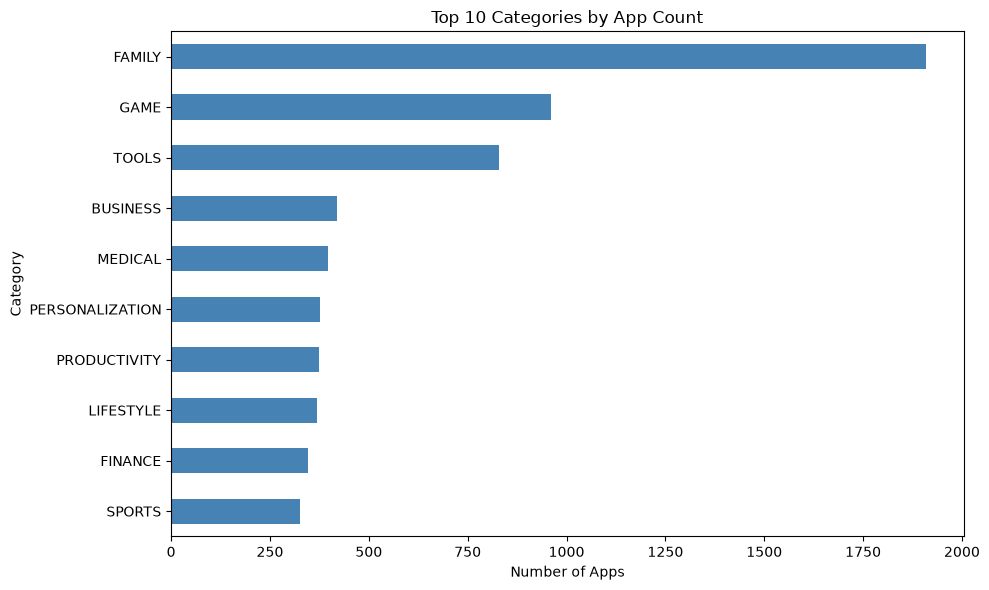

In [39]:
top_categories = apps['Category'].value_counts().head(10)

plt.figure(figsize=(10,6))
top_categories.plot(kind='barh', color='steelblue')
plt.xlabel('Number of Apps')
plt.title('Top 10 Categories by App Count')
plt.gca().invert_yaxis()  # largest at top
plt.tight_layout()
plt.show()


Mean: 295.3030303030303
Median: 219.0
Skewness: 3.364706135471712


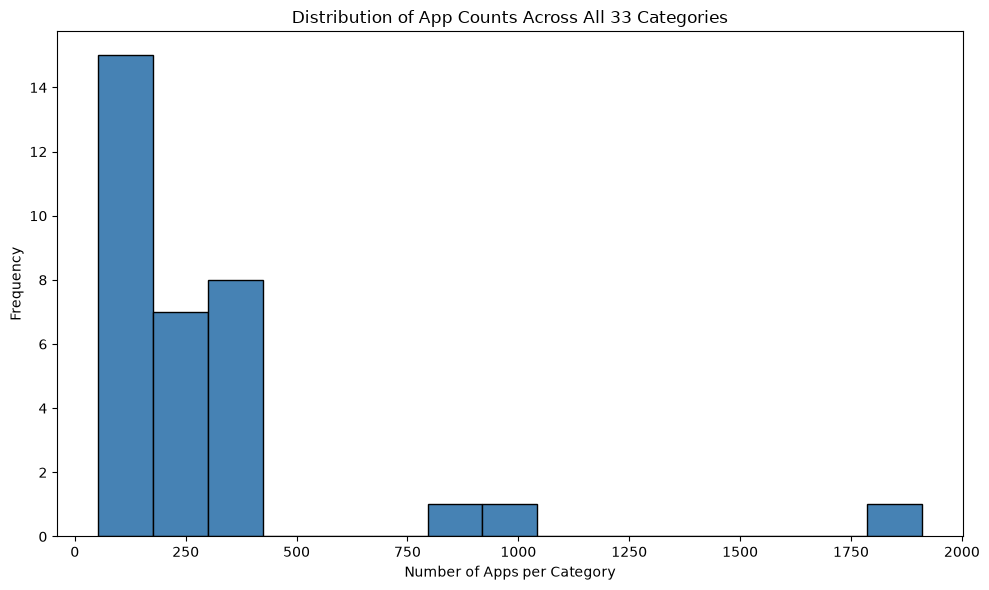

In [40]:
category_counts = apps['Category'].value_counts()

print('Mean:', category_counts.mean())
print('Median:', category_counts.median())
print('Skewness:', category_counts.skew())

plt.figure(figsize=(10,6))
category_counts.plot(kind='hist', bins=15, color='steelblue', edgecolor='black')
plt.xlabel('Number of Apps per Category')
plt.title('Distribution of App Counts Across All 33 Categories')
plt.tight_layout()
plt.show()

In [41]:
# What share of the whole dataset is FAMILY?
family_share = (apps['Category'] == 'FAMILY').sum() / len(apps) * 100
print(f'FAMILY makes up {family_share:.1f}% of all apps')
print()

# What sub-genres exist within FAMILY?
family_apps = apps[apps['Category'] == 'FAMILY']
print('Top Genre_Primary values within FAMILY:')
print(family_apps['Genre_Primary'].value_counts().head(15))

FAMILY makes up 19.6% of all apps

Top Genre_Primary values within FAMILY:
Genre_Primary
Entertainment    513
Education        478
Casual           208
Simulation       201
Puzzle           122
Role Playing     103
Educational      102
Strategy          87
Board             19
Racing            17
Arcade            15
Action            11
Adventure          7
Art & Design       4
Sports             4
Name: count, dtype: int64


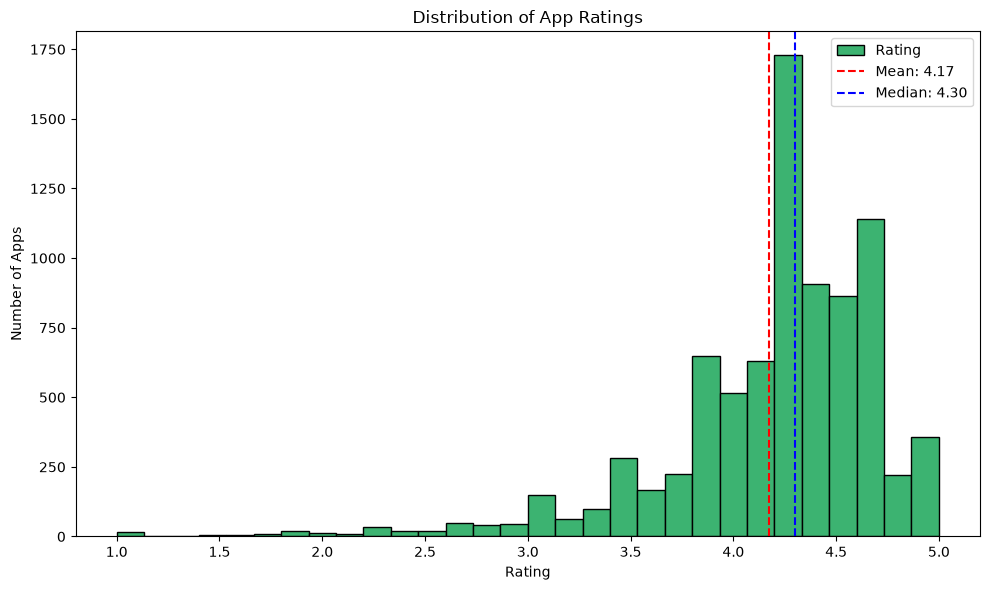

Skewness: -1.7549180210834416


In [42]:
plt.figure(figsize=(10,6))
apps['Rating'].plot(kind='hist', bins=30, color='mediumseagreen', edgecolor='black')
plt.xlabel('Rating')
plt.ylabel('Number of Apps')
plt.title('Distribution of App Ratings')
plt.axvline(apps['Rating'].mean(), color='red', linestyle='--', label=f"Mean: {apps['Rating'].mean():.2f}")
plt.axvline(apps['Rating'].median(), color='blue', linestyle='--', label=f"Median: {apps['Rating'].median():.2f}")
plt.legend()
plt.tight_layout()
plt.show()

print('Skewness:', apps['Rating'].skew())

In [43]:
print(apps['Last Updated'].dtype)
print(apps['Last Updated'].head(5))



object
0    2018-01-07 00:00:00
1    2018-01-15 00:00:00
2    2018-08-01 00:00:00
3    2018-06-08 00:00:00
4    2018-06-20 00:00:00
Name: Last Updated, dtype: object


In [44]:
apps['Last_Updated_Date'] = pd.to_datetime(apps['Last Updated'])

# Sanity checks
print(apps['Last_Updated_Date'].dtype)
print(apps[['Last Updated', 'Last_Updated_Date']].head(5))
print()
print('Nulls:', apps['Last_Updated_Date'].isna().sum())
print('Date range:', apps['Last_Updated_Date'].min(), 'to', apps['Last_Updated_Date'].max())

datetime64[us]
          Last Updated Last_Updated_Date
0  2018-01-07 00:00:00        2018-01-07
1  2018-01-15 00:00:00        2018-01-15
2  2018-08-01 00:00:00        2018-08-01
3  2018-06-08 00:00:00        2018-06-08
4  2018-06-20 00:00:00        2018-06-20

Nulls: 0
Date range: 2010-05-21 00:00:00 to 2018-08-08 00:00:00


In [45]:
apps.to_csv('googleplaystore_cleaned.csv', index=False)
apps.to_excel('googleplaystore_cleaned.xlsx', index=False)
print('Saved. Shape:', apps.shape)
print('Columns:', list(apps.columns))

Saved. Shape: (9745, 17)
Columns: ['App', 'Category', 'Rating', 'Reviews', 'Size', 'Installs', 'Type', 'Price', 'Content Rating', 'Genres', 'Last Updated', 'Current Ver', 'Android Ver', 'Size_MB', 'Genre_Primary', 'Genre_Secondary', 'Last_Updated_Date']


In [46]:
category_ratings = apps.groupby('Category')['Rating'].agg(['mean', 'count']).sort_values('mean', ascending=False)
category_ratings['mean'] = category_ratings['mean'].round(2)
print(category_ratings)

                     mean  count
Category                        
EVENTS               4.44     45
EDUCATION            4.36    118
ART_AND_DESIGN       4.36     61
BOOKS_AND_REFERENCE  4.34    169
PERSONALIZATION      4.33    298
PARENTING            4.30     50
BEAUTY               4.28     42
SOCIAL               4.25    203
GAME                 4.25    913
WEATHER              4.24     72
HEALTH_AND_FITNESS   4.24    244
SHOPPING             4.23    180
SPORTS               4.22    262
AUTO_AND_VEHICLES    4.19     73
FAMILY               4.19   1684
PRODUCTIVITY         4.18    301
COMICS               4.18     54
LIBRARIES_AND_DEMO   4.18     64
FOOD_AND_DRINK       4.17     94
MEDICAL              4.17    291
PHOTOGRAPHY          4.16    263
HOUSE_AND_HOME       4.15     62
ENTERTAINMENT        4.14    102
NEWS_AND_MAGAZINES   4.12    204
COMMUNICATION        4.12    257
FINANCE              4.12    302
BUSINESS             4.10    263
LIFESTYLE            4.09    302
TRAVEL_AND

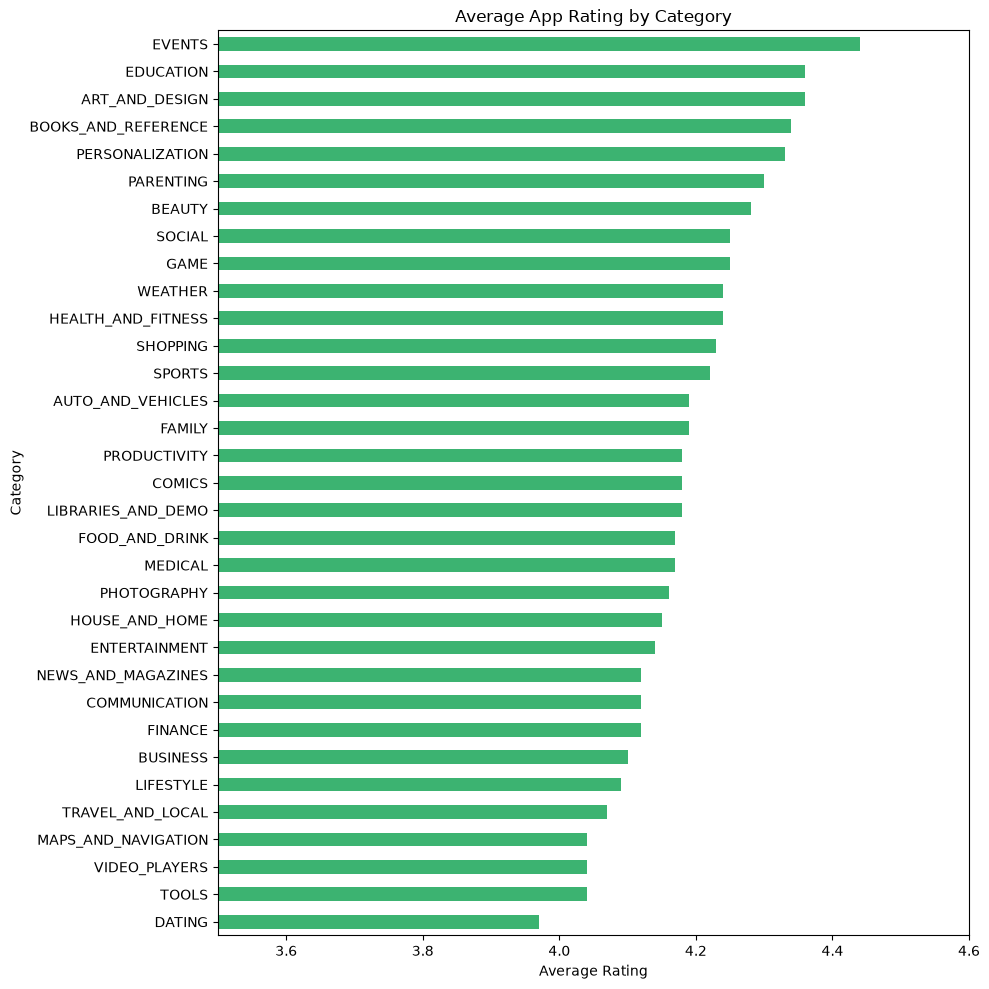

In [47]:
plt.figure(figsize=(10,10))
category_ratings['mean'].sort_values().plot(kind='barh', color='mediumseagreen')
plt.xlabel('Average Rating')
plt.title('Average App Rating by Category')
plt.xlim(3.5, 4.6)  # zoom in since the range is narrow
plt.tight_layout()
plt.show()

Rows available for this plot: 8495


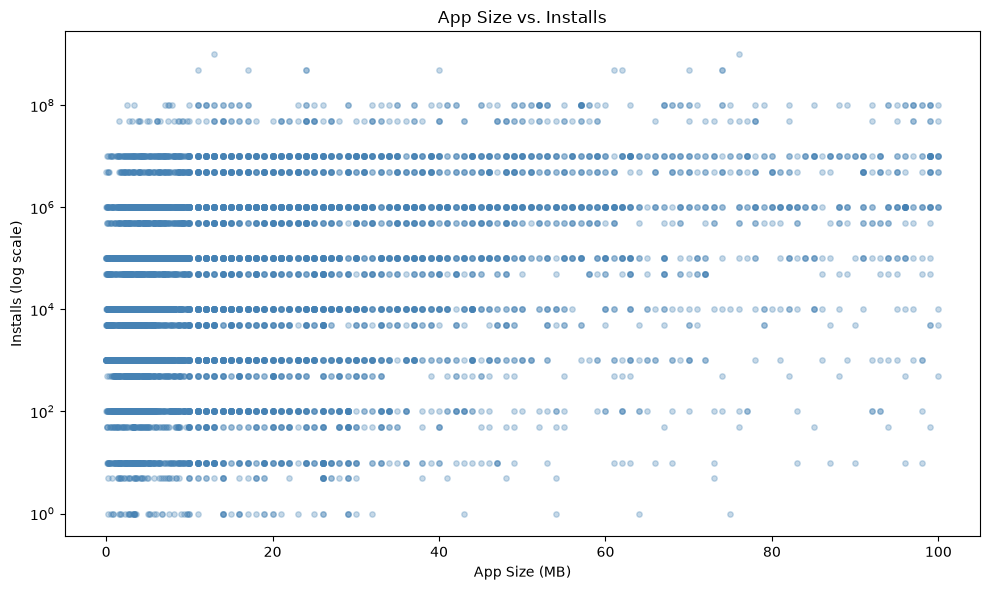

Pearson correlation (Size_MB vs Installs): 0.1436450592341313


In [48]:
plot_data = apps.dropna(subset=['Size_MB', 'Installs'])
print('Rows available for this plot:', len(plot_data))

plt.figure(figsize=(10,6))
plt.scatter(plot_data['Size_MB'], plot_data['Installs'], alpha=0.3, s=15, color='steelblue')
plt.yscale('log')
plt.xlabel('App Size (MB)')
plt.ylabel('Installs (log scale)')
plt.title('App Size vs. Installs')
plt.tight_layout()
plt.show()

# Quantify the relationship
correlation = plot_data['Size_MB'].corr(plot_data['Installs'])
print('Pearson correlation (Size_MB vs Installs):', correlation)

Type
Free    8988
Paid     757
Name: count, dtype: int64

Percent paid: 7.77 %


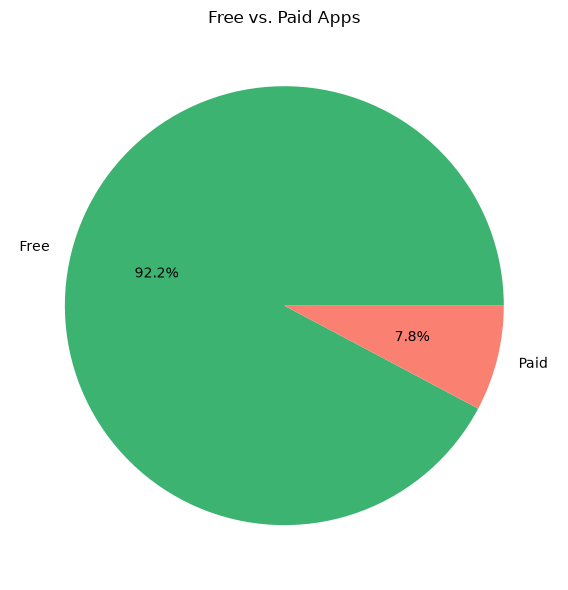

In [49]:
type_counts = apps['Type'].value_counts()
print(type_counts)
print()
print('Percent paid:', (type_counts['Paid'] / type_counts.sum() * 100).round(2), '%')

plt.figure(figsize=(6,6))
plt.pie(type_counts, labels=type_counts.index, autopct='%1.1f%%', colors=['mediumseagreen','salmon'])
plt.title('Free vs. Paid Apps')
plt.tight_layout()
plt.show()

count    757.000000
mean      14.022616
std       58.706603
min        0.990000
25%        1.490000
50%        2.990000
75%        4.990000
max      400.000000
Name: Price, dtype: float64



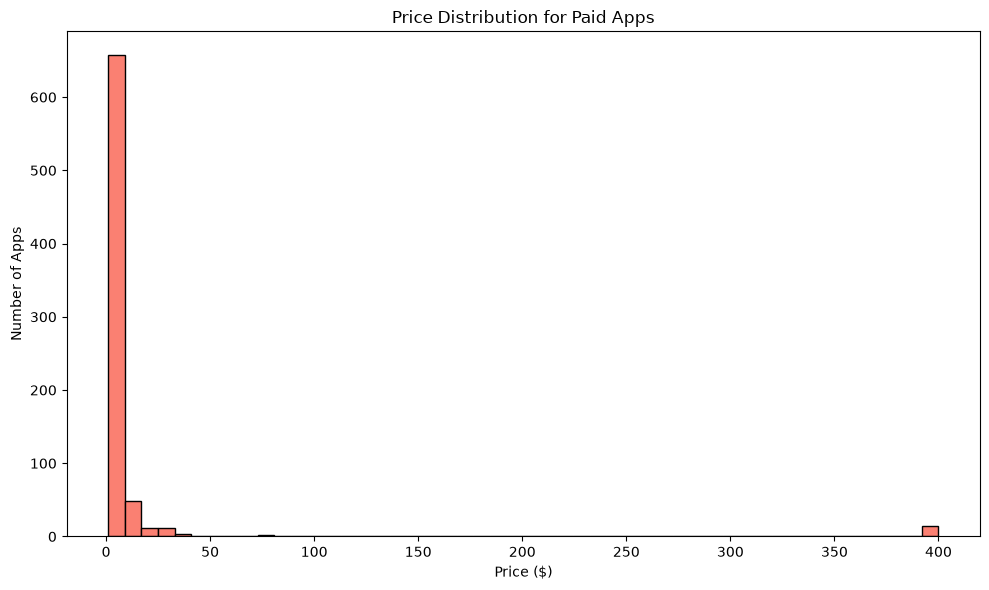

                                 App   Category   Price
3378        I'm Rich - Trump Edition  LIFESTYLE  400.00
3228          most expensive app (H)     FAMILY  399.99
3374                   üíé I'm rich  LIFESTYLE  399.99
4326                       I am rich  LIFESTYLE  399.99
4328                  I am Rich Plus     FAMILY  399.99
4330               I Am Rich Premium    FINANCE  399.99
4332                      I am Rich!    FINANCE  399.99
4333              I am rich(premium)    FINANCE  399.99
4336                   I Am Rich Pro     FAMILY  399.99
4338  I am rich (Most expensive app)    FINANCE  399.99


In [50]:
paid_apps = apps[apps['Type'] == 'Paid']

print(paid_apps['Price'].describe())
print()

plt.figure(figsize=(10,6))
paid_apps['Price'].plot(kind='hist', bins=50, color='salmon', edgecolor='black')
plt.xlabel('Price ($)')
plt.ylabel('Number of Apps')
plt.title('Price Distribution for Paid Apps')
plt.tight_layout()
plt.show()

# Look at the most expensive apps
print(paid_apps.nlargest(10, 'Price')[['App', 'Category', 'Price']])

In [51]:
# Search for the "I Am Rich" pattern across the whole app column (case-insensitive)
rich_apps = apps[apps['App'].str.contains('rich', case=False, na=False) & (apps['Price'] > 100)]
print('Suspected joke apps found:', len(rich_apps))
print(rich_apps[['App', 'Category', 'Price']])

Suspected joke apps found: 15
                                    App   Category   Price
3374                      üíé I'm rich  LIFESTYLE  399.99
3378           I'm Rich - Trump Edition  LIFESTYLE  400.00
4326                          I am rich  LIFESTYLE  399.99
4328                     I am Rich Plus     FAMILY  399.99
4329                      I am rich VIP  LIFESTYLE  299.99
4330                  I Am Rich Premium    FINANCE  399.99
4331                I am extremely Rich  LIFESTYLE  379.99
4332                         I am Rich!    FINANCE  399.99
4333                 I am rich(premium)    FINANCE  399.99
4336                      I Am Rich Pro     FAMILY  399.99
4338     I am rich (Most expensive app)    FINANCE  399.99
4340                          I Am Rich     FAMILY  389.99
4343                          I am Rich    FINANCE  399.99
4347                 I AM RICH PRO PLUS    FINANCE  399.99
8841  I'm Rich/Eu sou Rico/أنا غني/我很有錢  LIFESTYLE  399.99


In [52]:
# Broader net: any app priced above $100, regardless of name
expensive = apps[apps['Price'] > 100]
print('All apps priced above $100:', len(expensive))
print(expensive[['App', 'Category', 'Price']])

All apps priced above $100: 20
                                    App      Category   Price
3228             most expensive app (H)        FAMILY  399.99
3374                      üíé I'm rich     LIFESTYLE  399.99
3378           I'm Rich - Trump Edition     LIFESTYLE  400.00
4326                          I am rich     LIFESTYLE  399.99
4328                     I am Rich Plus        FAMILY  399.99
4329                      I am rich VIP     LIFESTYLE  299.99
4330                  I Am Rich Premium       FINANCE  399.99
4331                I am extremely Rich     LIFESTYLE  379.99
4332                         I am Rich!       FINANCE  399.99
4333                 I am rich(premium)       FINANCE  399.99
4336                      I Am Rich Pro        FAMILY  399.99
4338     I am rich (Most expensive app)       FINANCE  399.99
4340                          I Am Rich        FAMILY  389.99
4343                          I am Rich       FINANCE  399.99
4347                 I AM RICH PRO PLUS

In [53]:
joke_pattern = 'rich|eu sou rico'
is_joke = apps['App'].str.contains(joke_pattern, case=False, na=False) & (apps['Price'] > 100)

print('Joke apps to exclude:', is_joke.sum())
print(apps[is_joke][['App', 'Price']])

apps_for_revenue = apps[~is_joke].copy()
print()
print('Rows remaining for revenue analysis:', len(apps_for_revenue))

Joke apps to exclude: 16
                                    App   Price
3374                      üíé I'm rich  399.99
3378           I'm Rich - Trump Edition  400.00
4326                          I am rich  399.99
4328                     I am Rich Plus  399.99
4329                      I am rich VIP  299.99
4330                  I Am Rich Premium  399.99
4331                I am extremely Rich  379.99
4332                         I am Rich!  399.99
4333                 I am rich(premium)  399.99
4336                      I Am Rich Pro  399.99
4338     I am rich (Most expensive app)  399.99
4340                          I Am Rich  389.99
4343                          I am Rich  399.99
4347                 I AM RICH PRO PLUS  399.99
8824                        Eu Sou Rico  394.99
8841  I'm Rich/Eu sou Rico/أنا غني/我很有錢  399.99

Rows remaining for revenue analysis: 9729


In [54]:
joke_pattern = 'rich|eu sou rico'
is_joke = (
    apps['App'].str.contains(joke_pattern, case=False, na=False) & (apps['Price'] > 100)
) | (apps['App'] == 'most expensive app (H)')

print('Joke apps to exclude:', is_joke.sum())
print(apps[is_joke][['App', 'Price']])

apps_for_revenue = apps[~is_joke].copy()
print()
print('Rows remaining for revenue analysis:', len(apps_for_revenue))

# Confirm the legitimate expensive apps are still in
print()
print(apps_for_revenue[apps_for_revenue['Price'] > 100][['App', 'Category', 'Price']])

Joke apps to exclude: 17
                                    App   Price
3228             most expensive app (H)  399.99
3374                      üíé I'm rich  399.99
3378           I'm Rich - Trump Edition  400.00
4326                          I am rich  399.99
4328                     I am Rich Plus  399.99
4329                      I am rich VIP  299.99
4330                  I Am Rich Premium  399.99
4331                I am extremely Rich  379.99
4332                         I am Rich!  399.99
4333                 I am rich(premium)  399.99
4336                      I Am Rich Pro  399.99
4338     I am rich (Most expensive app)  399.99
4340                          I Am Rich  389.99
4343                          I am Rich  399.99
4347                 I AM RICH PRO PLUS  399.99
8824                        Eu Sou Rico  394.99
8841  I'm Rich/Eu sou Rico/أنا غني/我很有錢  399.99

Rows remaining for revenue analysis: 9728

                          App      Category   Price
5560  BP Fitnes

Category
FAMILY                 105741086.36
GAME                    40688636.85
PHOTOGRAPHY               8547767.7
PERSONALIZATION          6796947.56
LIFESTYLE                 6205149.4
MEDICAL                  5956236.67
TOOLS                    5464820.59
SPORTS                   4706211.95
PRODUCTIVITY             4313374.95
COMMUNICATION             4247364.5
WEATHER                   4181380.0
EDUCATION                 2403980.0
HEALTH_AND_FITNESS        1426068.9
MAPS_AND_NAVIGATION       1240789.0
TRAVEL_AND_LOCAL          1151504.4
Name: Estimated_Revenue, dtype: Float64


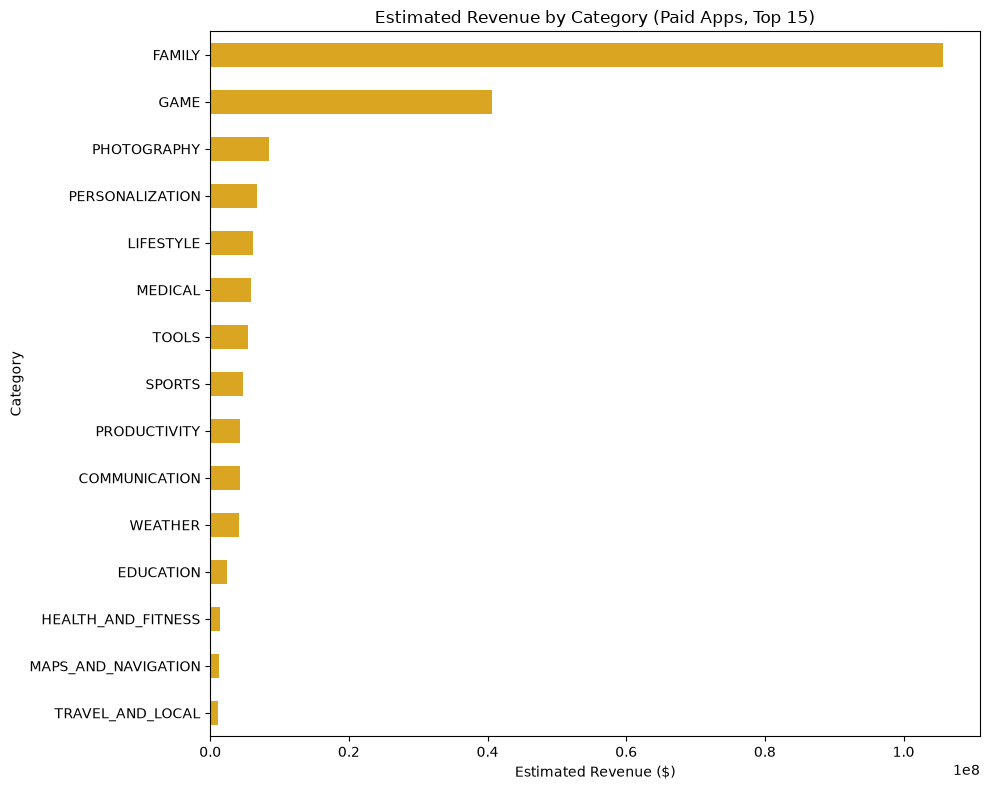

In [55]:
apps_for_revenue['Estimated_Revenue'] = apps_for_revenue['Price'] * apps_for_revenue['Installs']

revenue_by_category = (
    apps_for_revenue[apps_for_revenue['Type'] == 'Paid']
    .groupby('Category')['Estimated_Revenue']
    .sum()
    .sort_values(ascending=False)
)

print(revenue_by_category.head(15))

plt.figure(figsize=(10,8))
revenue_by_category.head(15).sort_values().plot(kind='barh', color='goldenrod')
plt.xlabel('Estimated Revenue ($)')
plt.title('Estimated Revenue by Category (Paid Apps, Top 15)')
plt.tight_layout()
plt.show()

In [56]:
reviews = pd.read_excel('googleplaystore_user_reviews.xlsx')

print(reviews.shape)
print(reviews.dtypes)
print()
print(reviews.isna().sum())
print()
reviews.head(10)

(64295, 5)
App                           str
Translated_Review          object
Sentiment                     str
Sentiment_Polarity        float64
Sentiment_Subjectivity    float64
dtype: object

App                           0
Translated_Review         26869
Sentiment                 26863
Sentiment_Polarity        26863
Sentiment_Subjectivity    26863
dtype: int64



,App,Translated_Review,Sentiment,Sentiment_Polarity,Sentiment_Subjectivity
0,10 Best Foods for You,I like eat delicious food. That's I'm cooking ...,Positive,1.00,0.533333
1,10 Best Foods for You,This help eating healthy exercise regular basis,Positive,0.25,0.288462
2,10 Best Foods for You,NaN,NaN,NaN,NaN
3,10 Best Foods for You,Works great especially going grocery store,Positive,0.40,0.875000
4,10 Best Foods for You,Best idea us,Positive,1.00,0.300000
5,10 Best Foods for You,Best way,Positive,1.00,0.300000
6,10 Best Foods for You,Amazing,Positive,0.60,0.900000
7,10 Best Foods for You,NaN,NaN,NaN,NaN
8,10 Best Foods for You,"Looking forward app,",Neutral,0.00,0.000000
9,10 Best Foods for You,It helpful site ! It help foods get !,Neutral,0.00,0.000000


In [57]:
import sys
!{sys.executable} -m pip install vaderSentiment

In [58]:
reviews_clean = reviews.dropna(subset=['Translated_Review']).copy()
print('Rows with review text:', len(reviews_clean))
print()
print(reviews_clean.head(5))

Rows with review text: 37426

                     App                                  Translated_Review  \
0  10 Best Foods for You  I like eat delicious food. That's I'm cooking ...   
1  10 Best Foods for You    This help eating healthy exercise regular basis   
3  10 Best Foods for You         Works great especially going grocery store   
4  10 Best Foods for You                                       Best idea us   
5  10 Best Foods for You                                           Best way   

  Sentiment  Sentiment_Polarity  Sentiment_Subjectivity  
0  Positive                1.00                0.533333  
1  Positive                0.25                0.288462  
3  Positive                0.40                0.875000  
4  Positive                1.00                0.300000  
5  Positive                1.00                0.300000  


In [59]:
# Find the non-string values
non_string = reviews_clean[~reviews_clean['Translated_Review'].apply(lambda x: isinstance(x, str))]
print('Non-string rows found:', len(non_string))
print(non_string[['App', 'Translated_Review']])


Non-string rows found: 1
                   App Translated_Review
44946  Fast Secure VPN             81759


In [60]:
reviews_clean = reviews_clean[reviews_clean['Translated_Review'].apply(lambda x: isinstance(x, str))].copy()
print('Rows remaining:', len(reviews_clean))

Rows remaining: 37425


In [61]:
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

analyzer = SentimentIntensityAnalyzer()

def get_vader_sentiment(text):
    scores = analyzer.polarity_scores(text)
    compound = scores['compound']
    if compound >= 0.05:
        label = 'Positive'
    elif compound <= -0.05:
        label = 'Negative'
    else:
        label = 'Neutral'
    return pd.Series([compound, label])

reviews_clean[['VADER_Compound', 'VADER_Sentiment']] = reviews_clean['Translated_Review'].apply(get_vader_sentiment)

print(reviews_clean[['Translated_Review', 'Sentiment', 'VADER_Sentiment', 'VADER_Compound']].head(10))
print()
print('VADER sentiment counts:')
print(reviews_clean['VADER_Sentiment'].value_counts())

                                    Translated_Review Sentiment  \
0   I like eat delicious food. That's I'm cooking ...  Positive   
1     This help eating healthy exercise regular basis  Positive   
3          Works great especially going grocery store  Positive   
4                                        Best idea us  Positive   
5                                            Best way  Positive   
6                                             Amazing  Positive   
8                                Looking forward app,   Neutral   
9               It helpful site ! It help foods get !   Neutral   
10                                          good you.  Positive   
11  Useful information The amount spelling errors ...  Positive   

   VADER_Sentiment  VADER_Compound  
0         Positive          0.9531  
1         Positive          0.6597  
3         Positive          0.6249  
4         Positive          0.6369  
5         Positive          0.6369  
6         Positive          0.5859  
8  

In [62]:
agreement = (reviews_clean['Sentiment'] == reviews_clean['VADER_Sentiment']).mean() * 100
print(f'Agreement between original Sentiment and VADER: {agreement:.1f}%')

print()
print('Cross-tab of original vs VADER labels:')
print(pd.crosstab(reviews_clean['Sentiment'], reviews_clean['VADER_Sentiment']))

Agreement between original Sentiment and VADER: 76.3%

Cross-tab of original vs VADER labels:
VADER_Sentiment  Negative  Neutral  Positive
Sentiment                                   
Negative             4837      697      2737
Neutral               952     2528      1677
Positive             1733     1079     21185


In [63]:
reviews_clean.to_csv('googleplaystore_user_reviews_cleaned.csv', index=False)
print('Saved. Shape:', reviews_clean.shape)

Saved. Shape: (37425, 7)


In [64]:
# Merge reviews with apps to get Category for each review
reviews_with_cat = reviews_clean.merge(apps[['App', 'Category']], on='App', how='left')

print('Reviews before merge:', len(reviews_clean))
print('Reviews after merge:', len(reviews_with_cat))
print()
print('Reviews with no matching Category (app not found in apps table):', reviews_with_cat['Category'].isna().sum())

Reviews before merge: 37425
Reviews after merge: 39763

Reviews with no matching Category (app not found in apps table): 3423


In [65]:
# Which apps are causing duplication (appear in reviews AND have 2+ categories in apps)?
dupe_causing_apps = reviews_with_cat['App'].value_counts()
merged_dupes = reviews_with_cat[reviews_with_cat.duplicated(subset=['App', 'Translated_Review'], keep=False)]
print('Example of a duplicated review:')
print(merged_dupes[['App', 'Translated_Review', 'Category']].head(6))
print()

# Which apps have no match at all?
unmatched = reviews_with_cat[reviews_with_cat['Category'].isna()]
print('Sample of unmatched app names:')
print(unmatched['App'].unique()[:15])

Example of a duplicated review:
                     App                                  Translated_Review  \
0  10 Best Foods for You  I like eat delicious food. That's I'm cooking ...   
1  10 Best Foods for You    This help eating healthy exercise regular basis   
2  10 Best Foods for You         Works great especially going grocery store   
3  10 Best Foods for You                                       Best idea us   
4  10 Best Foods for You                                           Best way   
5  10 Best Foods for You                                            Amazing   

             Category  
0  HEALTH_AND_FITNESS  
1  HEALTH_AND_FITNESS  
2  HEALTH_AND_FITNESS  
3  HEALTH_AND_FITNESS  
4  HEALTH_AND_FITNESS  
5  HEALTH_AND_FITNESS  

Sample of unmatched app names:
<StringArray>
[                                                                    '104 ÊâæÂ∑•‰Ωú - ÊâæÂ∑•‰Ωú ÊâæÊâìÂ∑• ÊâæÂÖºËÅ∑ Â±•Ê≠∑ÂÅ•Ê™¢ Â±•Ê≠∑Ë®∫ÁôÇÂÆ§',
                                                     

In [66]:
import ftfy

reviews_clean['App'] = reviews_clean['App'].apply(lambda x: ftfy.fix_text(x) if isinstance(x, str) else x)

# Re-run the merge
reviews_with_cat = reviews_clean.merge(apps[['App', 'Category']], on='App', how='left')

print('Reviews before merge:', len(reviews_clean))
print('Reviews after merge:', len(reviews_with_cat))
print('Reviews with no matching Category:', reviews_with_cat['Category'].isna().sum())

Reviews before merge: 37425
Reviews after merge: 39990
Reviews with no matching Category: 1498


In [67]:
# For apps with multiple categories, keep just the one with the higher Reviews count
apps_primary_category = (
    apps.sort_values('Reviews', ascending=False)
        .drop_duplicates(subset='App', keep='first')
        [['App', 'Category']]
)

reviews_with_cat = reviews_clean.merge(apps_primary_category, on='App', how='left')

print('Reviews before merge:', len(reviews_clean))
print('Reviews after merge:', len(reviews_with_cat))
print('Reviews with no matching Category:', reviews_with_cat['Category'].isna().sum())

Reviews before merge: 37425
Reviews after merge: 37425
Reviews with no matching Category: 1498


In [68]:
reviews_final = reviews_with_cat.dropna(subset=['Category']).copy()
print('Final rows for sentiment-by-category analysis:', len(reviews_final))
print()

# Sentiment breakdown by category (using our VADER labels)
sentiment_by_category = pd.crosstab(reviews_final['Category'], reviews_final['VADER_Sentiment'], normalize='index') * 100
sentiment_by_category = sentiment_by_category.round(1).sort_values('Positive', ascending=False)
print(sentiment_by_category)

Final rows for sentiment-by-category analysis: 35927

VADER_Sentiment      Negative  Neutral  Positive
Category                                        
COMICS                    2.2     11.1      86.7
AUTO_AND_VEHICLES         4.8     12.5      82.7
EVENTS                   12.0      7.6      80.4
HEALTH_AND_FITNESS       13.8      7.6      78.6
EDUCATION                11.3     11.3      77.5
ART_AND_DESIGN           12.1     11.5      76.3
PARENTING                10.4     15.8      73.8
GAME                     21.7      4.7      73.6
FAMILY                   17.3      9.6      73.1
FOOD_AND_DRINK           15.8     11.6      72.6
BOOKS_AND_REFERENCE      17.1     11.2      71.7
WEATHER                  17.9     11.4      70.6
LIBRARIES_AND_DEMO       18.9     11.1      70.0
MEDICAL                  16.6     13.7      69.6
PERSONALIZATION          18.0     12.4      69.6
PRODUCTIVITY             20.3     10.6      69.1
PHOTOGRAPHY              18.5     12.5      69.0
SHOPPING       

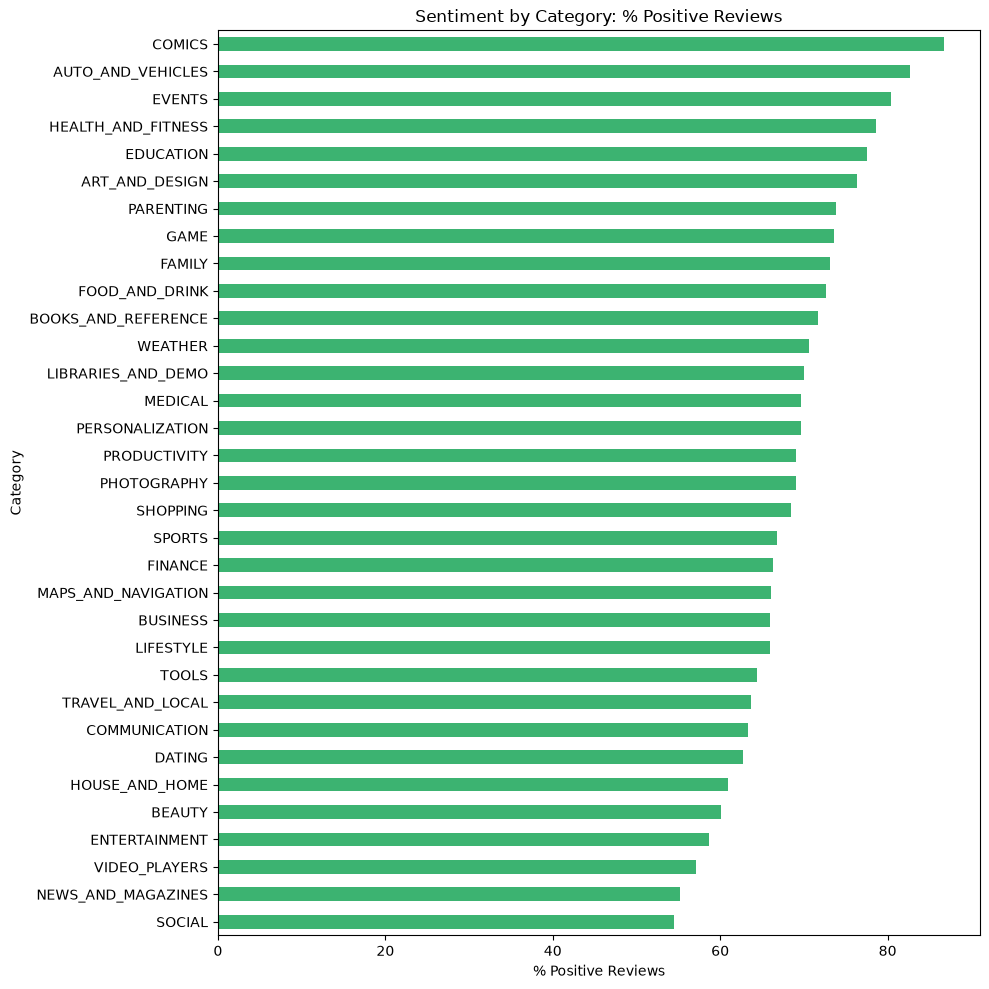

Saved reviews_final. Shape: (35927, 8)


In [69]:
plt.figure(figsize=(10,10))
sentiment_by_category['Positive'].sort_values().plot(kind='barh', color='mediumseagreen')
plt.xlabel('% Positive Reviews')
plt.title('Sentiment by Category: % Positive Reviews')
plt.tight_layout()
plt.show()

reviews_final.to_csv('googleplaystore_user_reviews_cleaned.csv', index=False)
print('Saved reviews_final. Shape:', reviews_final.shape)

In [70]:
import sys
!{sys.executable} -m pip install plotly

In [71]:
import plotly.express as px

plot_df = apps.dropna(subset=['Rating', 'Installs']).copy()

fig = px.scatter(
    plot_df,
    x='Installs',
    y='Rating',
    color='Category',
    size='Reviews',
    hover_name='App',
    log_x=True,
    title='App Rating vs. Installs (bubble size = Reviews, color = Category)',
    labels={'Installs': 'Installs (log scale)', 'Rating': 'Rating'},
    opacity=0.6
)
fig.update_layout(height=700)
fig.show()

## Conclusion: 3 Data-Driven Insights for a New App Developer

**1. Saturation & Opportunity**
FAMILY (1,909 apps) and GAME (913 apps) together make up nearly 30% of the entire Play Store dataset, making them the most crowded categories to break into. By contrast, smaller categories like EVENTS (only 45 apps) combine low competition with strong user reception — a 4.44 average rating (the highest of any category) and 80.4% positive sentiment. For a new developer, less-saturated categories may offer an easier path to visibility and positive reception than fighting for attention in an oversaturated space.

**2. App Size Has Little Bearing on Install Success**
The correlation between app size (MB) and number of installs was just 0.14 — effectively no meaningful relationship. Apps of every size, from a few KB to 100MB, span the full range of install counts. Developers shouldn't over-invest engineering effort in minimizing app size purely to drive downloads; that time is likely better spent on onboarding experience, marketing, or app store optimization (ASO).

**3. Pricing Norms and a Sentiment Warning Sign**
92.2% of apps in the store